In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import altair as alt

In [ ]:
df = pd.read_csv("df_final_no_outliers.csv")

In [ ]:
df_steph = df[df["PLAYER_NAME"]=="Kyrie Irving"]

model_standard = StandardScaler

df_steph_s = model_standard().fit_transform(X = df_steph[["Salary", "FG3A"]])



df_steph_s = pd.DataFrame(df_steph_s, columns = ["Salary", "FG3A"])
df_steph_s.reset_index(inplace=True)
year_list = pd.Series(df_steph["Year_List"])

year_list.reindex(range(8))

year_list = year_list.to_frame()

year_list.reset_index(inplace=True, drop = True)
year_list.reset_index(inplace=True)

print(year_list)
print(df_steph_s)
df_steph_n = pd.merge(df_steph_s, year_list, how = 'inner')
df_steph_n.head()

    index  Year_List
0       0       2011
1       1       2012
2       2       2013
3       3       2014
4       4       2015
5       5       2016
6       6       2017
7       7       2018
8       8       2019
9       9       2019
10     10       2020
11     11       2021
12     12       2022
    index    Salary      FG3A
0       0 -1.407805 -1.184511
1       1 -1.407805 -0.337850
2       2 -1.407805  0.235410
3       3 -1.407805  0.535269
4       4  0.254634 -0.487780
5       5  0.254634  1.090890
6       6  0.254634  0.791031
7       7  0.254634  1.029154
8       8  1.089513 -1.546106
9       9  0.254634 -1.546106
10     10  1.089513  0.535269
11     11  1.089513 -0.690626
12     12  1.089513  1.575956


,index,Salary,FG3A,Year_List
0,0,-1.407805,-1.184511,2011
1,1,-1.407805,-0.337850,2012
2,2,-1.407805,0.235410,2013
3,3,-1.407805,0.535269,2014
4,4,0.254634,-0.487780,2015


Rolling [window=2,center=False,axis=0]


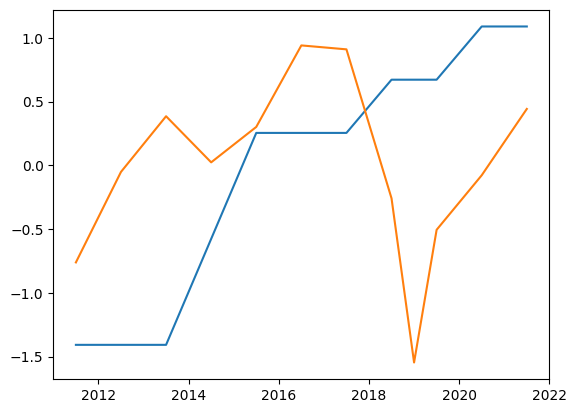

In [ ]:
print(df_steph_n["Salary"].iloc[:-1].rolling(window = 2))

plt.plot(df_steph_n["Year_List"].rolling(window=2).mean(), df_steph_n["Salary"].rolling(window = 2).mean())
plt.plot(df_steph_n["Year_List"].rolling(window=2).mean(), df_steph_n["FG3A"].rolling(window=2).mean())

plt.show()

In [ ]:
df.index

RangeIndex(start=0, stop=6305, step=1)

In [ ]:
df["Year_Future"] = df["Year_List"] + 1

In [ ]:
alt.data_transformers.disable_max_rows()
model_standard = StandardScaler

df_s = model_standard().fit_transform(X = df[["Salary", "FG3A"]])

df_s = pd.DataFrame(df_s, columns = ["Salary", "FG3A"])
df_s.reset_index(inplace=True)

df_s = pd.concat([df_s, df["Year_List"].astype(int), df["Year_Future"], df['PLAYER_ID']], axis = 1)

print(df_s.head())
base = alt.Chart(df_s).mark_line().encode(x = alt.X("Year_List", scale = alt.Scale(domain = [2010, 2023])), y = "FG3A", color = "Salary")

base

   index    Salary      FG3A  Year_List  Year_Future  PLAYER_ID
0      0 -1.362133 -0.296451       2011         2012     201985
1      1 -0.228637 -0.905850       2011         2012     201189
2      2 -0.966039 -0.905850       2011         2012     201189
3      3  0.648831  1.192421       2011         2012       1733
4      4  1.170248 -0.898925       2011         2012     201143


alt.Chart(...)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0b855501-6f2c-4764-816d-be07593df653' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>